# **ZONDE API Skew-T Log-P Diagram**

***사용 전 참고***
* 기상청 API 허브에서 ZPONDE ZPI를 발급받아 간단히 수업 실습용으로 제작한 IPYNB
* API KEY 및 URL 변수에는 본인이 직접 발급받은 주소를 입력해야 함
* 이후 사이트 제작 및 업데이트 예정

## **API VALUES**
발급받은 API KEY와 URL 저장하는 부분

### **URL (API KEY)**

In [ ]:
url=''

### **SAVE PATH**

In [7]:
original_path='original.txt'

## **IMPORTS**
사용할 모듈 수입

In [8]:
import requests
from pathlib import Path
import codecs
import pandas as pd
import metpy.calc as mpcalc
import numpy
import matplotlib.pyplot as plt
from metpy.plots import SkewT
from metpy.units import units
from metpy.calc import lcl, cape_cin, wind_components, parcel_profile

## **MAIN**
본격적으로 실행할 코드

### **DEFAULT DIAGRAM**
Plain 단열선도 출력
저장 기능은 아래 별도로 안내되어 있음

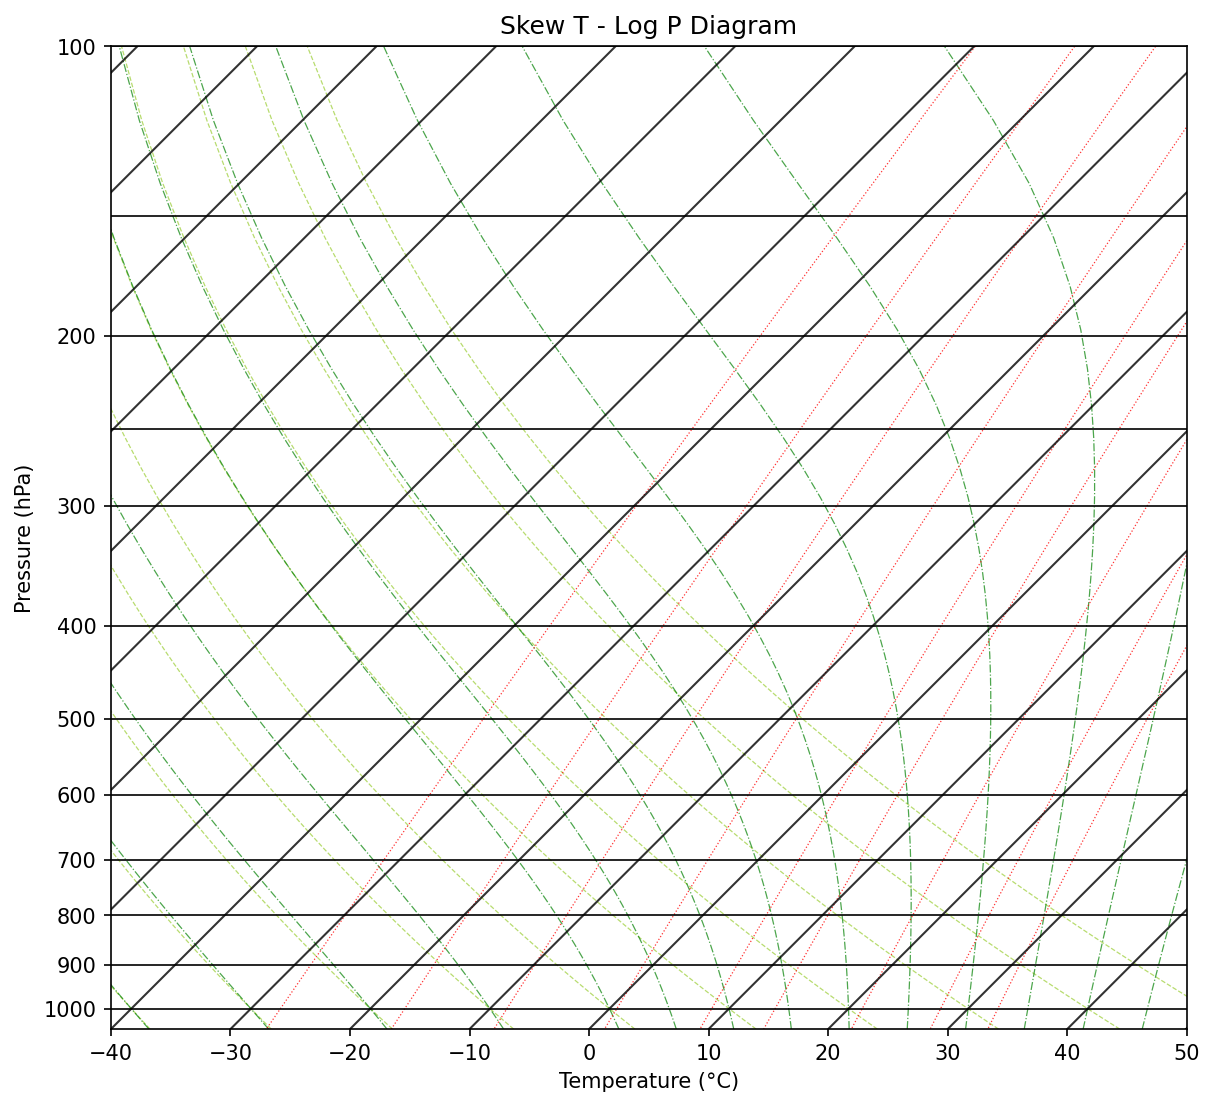

In [9]:
plt.rcParams.update(
    {
        'figure.dpi': 150,
        'axes.edgecolor': 'black',
        'axes.labelcolor': 'black',
        'text.color': 'black',
        'xtick.color': 'black',
        'ytick.color': 'black'
    }
)

def draw_back(skew, Tmin_lines=-130, Tmax=50, Tmin_xlim=-40):
    ax=skew.ax

    for p in [1000,900,800,700,600,500,400,300,250,200,150,100]:
        ax.axhline(p, lw=0.8, color='k')
    for T in range(Tmin_lines, Tmax+1, 10):
        ax.axvline(T, lw=1.0, color='k', alpha=0.8)

    skew.plot_dry_adiabats(colors='yellowgreen', linewidth=0.6, linestyle='--', alpha=0.7)
    skew.plot_moist_adiabats(colors='g', linewidth=0.6, linestyle='-.', alpha=0.7)
    skew.plot_mixing_lines(colors='r', linewidth=0.6, linestyle=':', alpha=0.8, pressure=numpy.arange(100, 1051, 10) * units.hPa)

    ax.set_ylim(1050, 100)
    ax.set_xlim(Tmin_xlim, Tmax)
    ax.set_xlabel('Temperature (°C)')
    ax.set_ylabel('Pressure (hPa)')

    ax.grid(False)
    ax.axvline(Tmax, color='k', linewidth=1.5)

fig = plt.figure(figsize=(8.2, 10.0))
skew = SkewT(fig, rotation=45)
draw_back(skew, Tmin_lines=-130, Tmax=50, Tmin_xlim=-40)
plt.title('Skew T - Log P Diagram', loc='center', fontsize=12)
plt.tight_layout()
plt.show()

**단열선도를 저장하는 방법**은 **plt.savefig()** 코드를 위 코드의 **plt.show()** 전에 추가

### **API ANALYZE**
API를 통해 당일 관측한 데이터를 수집해 단열선도 분석

C:\Users\MSI\AppData\Local\Temp\ipykernel_30816\849955439.py:15: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


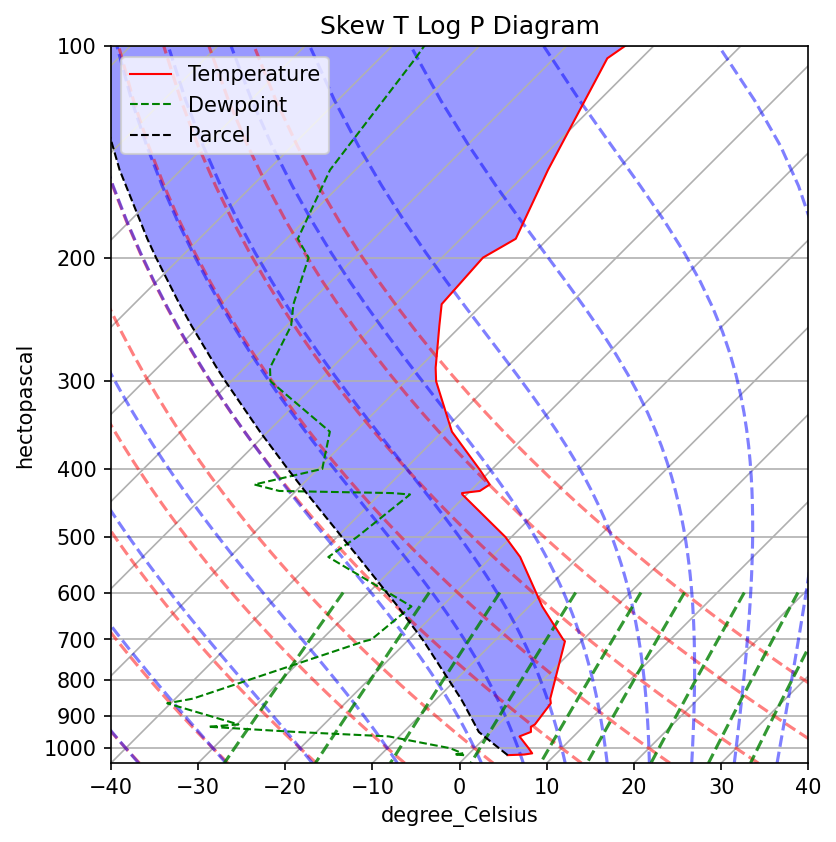

In [10]:
def download_file(file_url, save_path):
    with open(save_path, 'wb') as f:
        response=requests.get(file_url)
        f.write(response.content)

def convert_encoding(file_path, from_encoding, to_encoding):
    with codecs.open(file_path, 'r', from_encoding) as file:
        content = file.read()
    with codecs.open(file_path, 'w', to_encoding) as file:
        file.write(content)

download_file(url, original_path)
convert_encoding(original_path, 'euc-kr', 'utf-8')

df = pd.read_csv(
    "original.txt",
    delim_whitespace=True,
    comment="#",
    header=None,
    names=["YYMMDDHHMI", "STN", "PA", "GH", "TA", "TD", "WD", "WS", "FLAG"],
    na_values=-999.0
)

df["datetime"] = pd.to_datetime(df["YYMMDDHHMI"], format="%Y%m%d%H%M")

p = list(df['PA'])[::-1] * units.hPa
t = list(df['TA'])[::-1] * units.degC
td = list(df['TD'])[::-1] * units.degC

df_clean = df.dropna(subset=['PA', 'TA', 'TD'])
df_clean = df_clean.sort_values('PA', ascending=False)

p = df_clean['PA'].values * units.hPa
t = df_clean['TA'].values * units.degC
td = df_clean['TD'].values * units.degC

lcl_p, lcl_t = mpcalc.lcl(p[0], t[0], td[0])
ccl_p, ccl_t, t_c = mpcalc.ccl(p, t, td)
lfc_p, lfc_t = mpcalc.lfc(p, t, td, which='bottom')
el_p, el_t = mpcalc.el(p, t, td)
prof = mpcalc.parcel_profile(p, t[0], td[0]).to('degC')
cape, cin = mpcalc.cape_cin(p, t, td, prof)

fig = plt.figure(figsize=(6, 9))
skew = SkewT(fig, rotation=45)

skew.plot(p, t, 'r', linewidth=1, label='Temperature')
skew.plot(p, td, 'g', linewidth=1, linestyle='dashed', label='Dewpoint')
skew.plot(p, prof, 'k', linewidth=1, linestyle='dashed', label='Parcel')

skew.plot_dry_adiabats()
skew.plot_moist_adiabats()
skew.plot_mixing_lines()

skew.shade_cape(p, t, prof, facecolor='r')
skew.shade_cin(p, t, prof, facecolor='b')

skew.ax.set_ylim(1050, 100)
skew.ax.set_xlim(-40, 40)
skew.ax.set_title("Skew T Log P Diagram")

plt.legend()
plt.show()